# Renewable Energy Generation Forecasting

1. Background & Context Renewable energy sources like solar power are inherently intermittent. Without reliable short-term forecasting, power grids struggle with balancing supply and demand, often forcing reliance on backup fossil fuels.

2. The Challenge Statement Create a time-series forecasting model combining historical solar array output and localized cloud-cover imagery to predict short-term grid power generation and grid-balancing needs.

3. Core Solution Objectives (The Formula)
●    AI: Hybrid computer vision (for cloud imagery) and time-series forecasting neural networks.
●    Data: NREL Solar Resource Data, Kaggle Solar Power Datasets.
●    Sustainability: Maximize grid integration of clean energy and reduce dependency on peaker fossil fuel plants.
●    Measurable Impact: Percentage improvement in 24-hour generation forecasting accuracy and reduction in grid curtailment waste.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sma
from scipy import stats
import math as m
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import QuantileTransformer 

import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor,AdaBoostRegressor)
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (r2_score,mean_absolute_error,mean_absolute_percentage_error,mean_squared_error)

## Data Importing and Transformation

In [2]:
energy_df = pd.read_csv(r'energy_dataset.csv')
energy_df.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [3]:
energy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null  float64
 10

In [4]:
energy_df.shape

(35064, 29)

In [5]:
weather_df = pd.read_csv(r'weather_features.csv')
weather_df.head()

,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
3,2015-01-01 03:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n
4,2015-01-01 04:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


In [6]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178396 entries, 0 to 178395
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt_iso               178396 non-null  object 
 1   city_name            178396 non-null  object 
 2   temp                 178396 non-null  float64
 3   temp_min             178396 non-null  float64
 4   temp_max             178396 non-null  float64
 5   pressure             178396 non-null  int64  
 6   humidity             178396 non-null  int64  
 7   wind_speed           178396 non-null  int64  
 8   wind_deg             178396 non-null  int64  
 9   rain_1h              178396 non-null  float64
 10  rain_3h              178396 non-null  float64
 11  snow_3h              178396 non-null  float64
 12  clouds_all           178396 non-null  int64  
 13  weather_id           178396 non-null  int64  
 14  weather_main         178396 non-null  object 
 15  weather_descripti

In [7]:
weather_df.shape

(178396, 17)

In [48]:
# Droping irrelevant energy columns (Keeping only solar and load variables)
energy_cols_to_drop = [
    'generation biomass', 'generation fossil brown coal/lignite', 
    'generation fossil coal-derived gas', 'generation fossil gas', 
    'generation fossil hard coal', 'generation fossil oil', 
    'generation fossil oil shale', 'generation fossil peat', 
    'generation geothermal', 'generation hydro pumped storage aggregated', 
    'generation hydro pumped storage consumption', 
    'generation hydro run-of-river and poundage', 
    'generation hydro water reservoir', 'generation marine', 
    'generation nuclear', 'generation other', 
    'generation other renewable', 'generation waste', 
    'generation wind offshore', 'generation wind onshore', 
    'forecast wind offshore eday ahead', 'forecast wind onshore day ahead',
    'price day ahead', 'price actual'
]
energy_df = energy_df.drop(columns=energy_cols_to_drop, errors='ignore')
weather_df['city_name'] = weather_df['city_name'].str.strip()
weather_df = weather_df.drop(columns=['weather_icon', 'weather_id', 'temp_min', 'temp_max'], errors='ignore')
weather_df = weather_df.drop_duplicates(subset=['dt_iso', 'city_name'])

weather_pivoted = weather_df.pivot(index='dt_iso', columns='city_name')

weather_pivoted.columns = [f"{city}_{col}" for col, city in weather_pivoted.columns]
weather_pivoted = weather_pivoted.reset_index()

energy_df['time'] = pd.to_datetime(energy_df['time'], utc=True)
weather_pivoted['dt_iso'] = pd.to_datetime(weather_pivoted['dt_iso'], utc=True)

final_df = pd.merge(energy_df, weather_pivoted, left_on='time', right_on='dt_iso', how='inner')
final_df = final_df.drop(columns=['dt_iso'])

In [9]:
final_df.to_csv("cleaned_solar_final_data.csv", index=False)
print("Export complete. Shape:", final_df.shape)

Export complete. Shape: (35064, 60)


In [49]:
final_df.shape

(35064, 60)

In [52]:
final_df.head()

,time,generation solar,forecast solar day ahead,total load forecast,total load actual,Barcelona_temp,Bilbao_temp,Madrid_temp,Seville_temp,Valencia_temp,...,Barcelona_weather_main,Bilbao_weather_main,Madrid_weather_main,Seville_weather_main,Valencia_weather_main,Barcelona_weather_description,Bilbao_weather_description,Madrid_weather_description,Seville_weather_description,Valencia_weather_description
0,2014-12-31 23:00:00+00:00,49.0,17.0,26118.0,25385.0,281.625,269.657312,267.325,273.375,270.475,...,clear,clear,clear,clear,clear,sky is clear,sky is clear,sky is clear,sky is clear,sky is clear
1,2015-01-01 00:00:00+00:00,50.0,16.0,24934.0,24382.0,281.625,269.763500,267.325,273.375,270.475,...,clear,clear,clear,clear,clear,sky is clear,sky is clear,sky is clear,sky is clear,sky is clear
2,2015-01-01 01:00:00+00:00,50.0,8.0,23515.0,22734.0,281.286,269.251688,266.186,274.086,269.686,...,clear,clear,clear,clear,clear,sky is clear,sky is clear,sky is clear,sky is clear,sky is clear
3,2015-01-01 02:00:00+00:00,50.0,2.0,22642.0,21286.0,281.286,269.203344,266.186,274.086,269.686,...,clear,clear,clear,clear,clear,sky is clear,sky is clear,sky is clear,sky is clear,sky is clear
4,2015-01-01 03:00:00+00:00,42.0,9.0,21785.0,20264.0,281.286,269.485500,266.186,274.086,269.686,...,clear,clear,clear,clear,clear,sky is clear,sky is clear,sky is clear,sky is clear,sky is clear


In [51]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 60 columns):
 #   Column                         Non-Null Count  Dtype              
---  ------                         --------------  -----              
 0   time                           35064 non-null  datetime64[ns, UTC]
 1   generation solar               35046 non-null  float64            
 2   forecast solar day ahead       35064 non-null  float64            
 3   total load forecast            35064 non-null  float64            
 4   total load actual              35028 non-null  float64            
 5   Barcelona_temp                 35064 non-null  float64            
 6   Bilbao_temp                    35064 non-null  float64            
 7   Madrid_temp                    35064 non-null  float64            
 8   Seville_temp                   35064 non-null  float64            
 9   Valencia_temp                  35064 non-null  float64            
 10  Barcelona_pressure    

In [10]:
final_df.columns

Index(['time', 'generation solar', 'forecast solar day ahead',
       'total load forecast', 'total load actual', 'Barcelona_temp',
       'Bilbao_temp', 'Madrid_temp', 'Seville_temp', 'Valencia_temp',
       'Barcelona_pressure', 'Bilbao_pressure', 'Madrid_pressure',
       'Seville_pressure', 'Valencia_pressure', 'Barcelona_humidity',
       'Bilbao_humidity', 'Madrid_humidity', 'Seville_humidity',
       'Valencia_humidity', 'Barcelona_wind_speed', 'Bilbao_wind_speed',
       'Madrid_wind_speed', 'Seville_wind_speed', 'Valencia_wind_speed',
       'Barcelona_wind_deg', 'Bilbao_wind_deg', 'Madrid_wind_deg',
       'Seville_wind_deg', 'Valencia_wind_deg', 'Barcelona_rain_1h',
       'Bilbao_rain_1h', 'Madrid_rain_1h', 'Seville_rain_1h',
       'Valencia_rain_1h', 'Barcelona_rain_3h', 'Bilbao_rain_3h',
       'Madrid_rain_3h', 'Seville_rain_3h', 'Valencia_rain_3h',
       'Barcelona_snow_3h', 'Bilbao_snow_3h', 'Madrid_snow_3h',
       'Seville_snow_3h', 'Valencia_snow_3h', 'Barcelona_c

In [11]:
final_df.isnull().sum()

time                              0
generation solar                 18
forecast solar day ahead          0
total load forecast               0
total load actual                36
Barcelona_temp                    0
Bilbao_temp                       0
Madrid_temp                       0
Seville_temp                      0
Valencia_temp                     0
Barcelona_pressure                0
Bilbao_pressure                   0
Madrid_pressure                   0
Seville_pressure                  0
Valencia_pressure                 0
Barcelona_humidity                0
Bilbao_humidity                   0
Madrid_humidity                   0
Seville_humidity                  0
Valencia_humidity                 0
Barcelona_wind_speed              0
Bilbao_wind_speed                 0
Madrid_wind_speed                 0
Seville_wind_speed                0
Valencia_wind_speed               0
Barcelona_wind_deg                0
Bilbao_wind_deg                   0
Madrid_wind_deg             

In [12]:
cat_cols = ('Barcelona_weather_main', 'Bilbao_weather_main', 'Madrid_weather_main', 'Seville_weather_main', 'Valencia_weather_main',
            'Barcelona_weather_description', 'Bilbao_weather_description', 'Madrid_weather_description', 'Seville_weather_description', 
            'Valencia_weather_description')

num_cols = num_cols = [col for col in final_df.columns if col not in cat_cols]

In [13]:
for i in cat_cols:
    print(f' for {i}:\n{final_df[i].value_counts(normalize=True)}\n')

 for Barcelona_weather_main:
Barcelona_weather_main
clouds          0.459389
clear           0.420888
rain            0.096053
mist            0.010352
thunderstorm    0.006103
drizzle         0.005076
fog             0.001683
snow            0.000399
dust            0.000057
Name: proportion, dtype: float64

 for Bilbao_weather_main:
Bilbao_weather_main
clouds          0.476557
clear           0.241016
rain            0.202059
mist            0.034594
fog             0.026380
drizzle         0.010124
thunderstorm    0.004392
snow            0.003137
haze            0.001740
Name: proportion, dtype: float64

 for Madrid_weather_main:
Madrid_weather_main
clear           0.580424
clouds          0.303531
rain            0.067904
mist            0.017539
fog             0.013290
drizzle         0.011037
thunderstorm    0.004677
snow            0.001141
haze            0.000456
Name: proportion, dtype: float64

 for Seville_weather_main:
Seville_weather_main
clear           0.672399
clouds

In [14]:
final_df.shape

(35064, 60)

In [15]:
final_df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
generation solar,35046.0,1432.665925,1680.119887,0.000000,71.000000,616.00000,2578.00,5792.000
forecast solar day ahead,35064.0,1439.066735,1677.703355,0.000000,69.000000,576.00000,2636.00,5836.000
total load forecast,35064.0,28712.129962,4594.100854,18105.000000,24793.750000,28906.00000,32263.25,41390.000
total load actual,35028.0,28696.939905,4574.987950,18041.000000,24807.750000,28901.00000,32192.00,41015.000
Barcelona_temp,35064.0,289.867178,6.723623,262.240000,284.707375,289.41125,295.15,309.150
Bilbao_temp,35064.0,286.443451,6.803527,266.850000,281.452594,286.17000,291.04,312.470
Madrid_temp,35064.0,288.277131,9.326993,264.132000,281.150000,286.93000,294.95,313.330
Seville_temp,35064.0,293.166541,8.082475,271.050000,287.330000,292.44000,298.88,315.600
Valencia_temp,35064.0,290.783954,7.234569,268.830656,285.150000,290.19000,296.15,311.150
Barcelona_pressure,35064.0,1287.211356,13463.025220,0.000000,1014.000000,1017.00000,1021.00,1008371.000


## Outlier Treatment

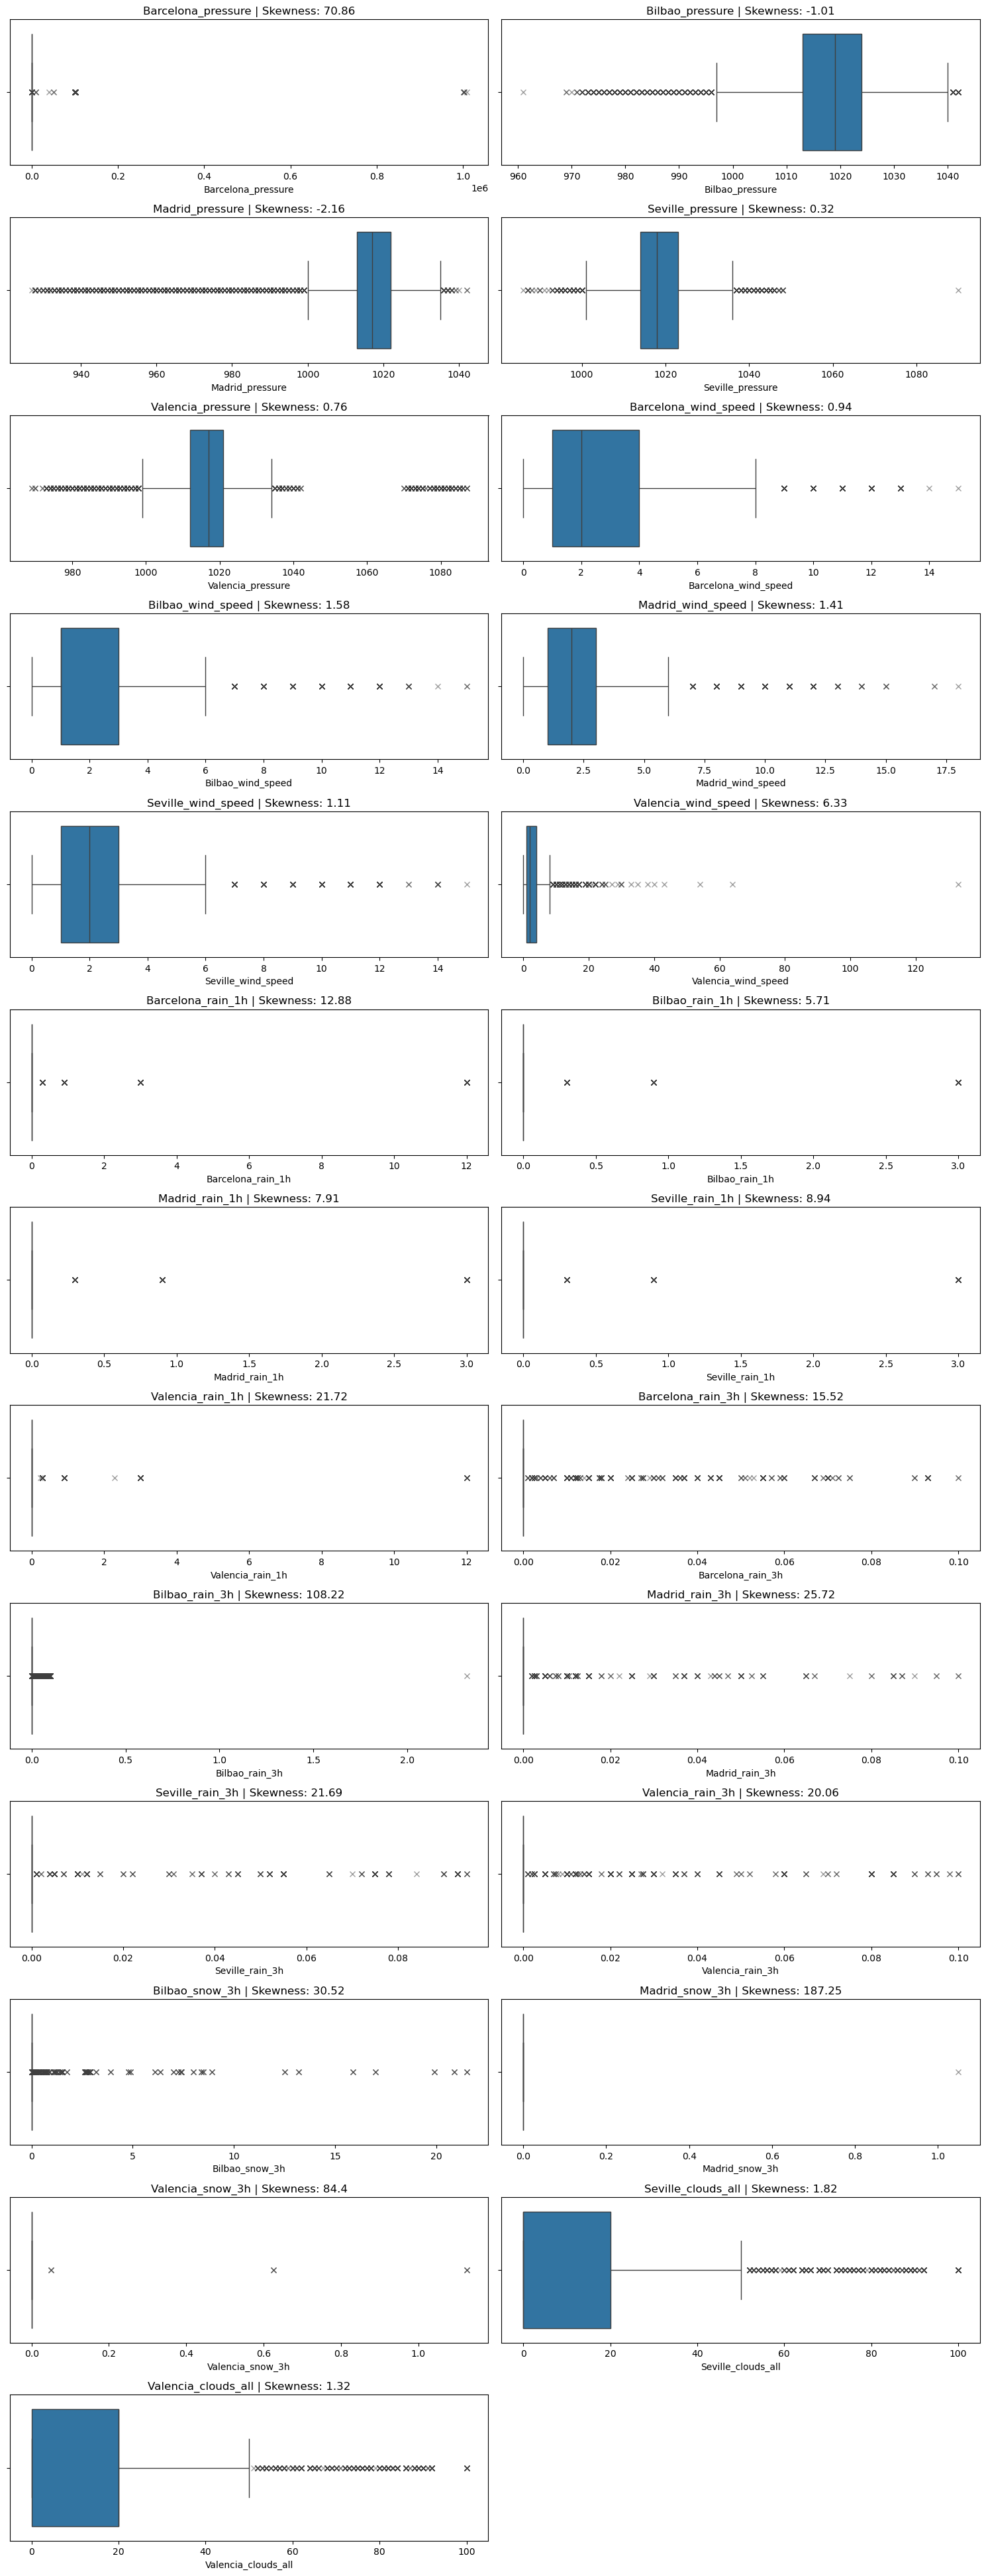

In [16]:
extreme_outlier_cols = []

for col in num_cols:
    Q1 = final_df[col].quantile(0.25)
    Q3 = final_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    if ((final_df[col] < lower_bound) | (final_df[col] > upper_bound)).any():
        extreme_outlier_cols.append(col)
        
t = 1
n_rows = m.ceil(len(extreme_outlier_cols) / 2) 
plt.figure(figsize=(15, 3 * n_rows)) 

for i in extreme_outlier_cols:
    plt.subplot(n_rows, 2, t)
    plt.title(f'{i} | Skewness: {round(final_df[i].skew(), 2)}')
    sns.boxplot(
        data=final_df, 
        x=i, 
        flierprops={"marker": "x", "color": "red", "alpha": 0.5}
    )
    t += 1
plt.tight_layout()
plt.show()

In [53]:
# Converting into Logs
initial_skew = final_df[num_cols].skew(numeric_only=True)

skewed_cols = initial_skew[abs(initial_skew) > 1.5].index.tolist()
print(f"Found {len(skewed_cols)} highly skewed columns.")

# Apply the log transformation
for col in skewed_cols:
    min_val = final_df[col].min()
    if min_val < 0:
        final_df[col] = np.log1p(final_df[col] - min_val)
    else:
        final_df[col] = np.log1p(final_df[col])

new_skew = final_df[skewed_cols].skew(numeric_only=True)

comparison = pd.DataFrame({
    'Original Skew': initial_skew[skewed_cols],
    'Logged Skew': new_skew
})
print(comparison.head(19))

Found 18 highly skewed columns.
                     Original Skew  Logged Skew
Barcelona_pressure       70.864135    22.843159
Madrid_pressure          -2.161936    -2.195913
Bilbao_wind_speed         1.582675     0.151116
Valencia_wind_speed       6.329593     0.110144
Barcelona_rain_1h        12.883641     6.002245
Bilbao_rain_1h            5.711228     3.644733
Madrid_rain_1h            7.907259     5.116731
Seville_rain_1h           8.940963     5.897871
Valencia_rain_1h         21.716698     8.386904
Barcelona_rain_3h        15.518524    15.339492
Bilbao_rain_3h          108.224052    49.981032
Madrid_rain_3h           25.718459    25.379816
Seville_rain_3h          21.688697    21.537262
Valencia_rain_3h         20.058120    19.818653
Bilbao_snow_3h           30.517545    18.732471
Madrid_snow_3h          187.253838   187.253838
Valencia_snow_3h         84.400897    81.046406
Seville_clouds_all        1.817588     0.973562


In [18]:
# winsorization skewness
initial_skew = final_df[num_cols].skew(numeric_only=True)
highly_skewed_cols = initial_skew[abs(initial_skew) > 1.5].index.tolist()

temp_df = final_df.copy()
for col in highly_skewed_cols:
    lower_limit = temp_df[col].quantile(0.01)
    upper_limit = temp_df[col].quantile(0.99)
    temp_df[col] = temp_df[col].clip(lower=lower_limit, upper=upper_limit)

new_skew = temp_df[highly_skewed_cols].skew(numeric_only=True)
comparison = pd.DataFrame({
    'Original Skewness': initial_skew[highly_skewed_cols],
    'Winsorization Skewness': new_skew})
print(comparison)

                    Original Skewness  Winsorization Skewness
Barcelona_pressure          22.843159               -0.309587
Madrid_pressure             -2.195913               -2.164254
Barcelona_rain_1h            6.002245                5.037542
Bilbao_rain_1h               3.644733                3.644733
Madrid_rain_1h               5.116731                4.247303
Seville_rain_1h              5.897871                4.584195
Valencia_rain_1h             8.386904                5.436021
Barcelona_rain_3h           15.339492                9.068490
Bilbao_rain_3h              49.981032                8.065920
Madrid_rain_3h              25.379816                0.000000
Seville_rain_3h             21.537262                0.000000
Valencia_rain_3h            19.818653                0.000000
Bilbao_snow_3h              18.732471                0.000000
Madrid_snow_3h             187.253838                0.000000
Valencia_snow_3h            81.046406                0.000000


In [19]:
# Quantile Transformation
initial_skew = final_df[num_cols].skew(numeric_only=True)
highly_skewed_cols = initial_skew[abs(initial_skew) > 1.5].index.tolist()

temp_df = final_df.copy()

qt = QuantileTransformer(output_distribution='normal', random_state=42)
temp_df[highly_skewed_cols] = qt.fit_transform(temp_df[highly_skewed_cols])
new_skew = temp_df[highly_skewed_cols].skew(numeric_only=True)

comparison = pd.DataFrame({
    'Original Skewness': initial_skew[highly_skewed_cols],
    'Quantile Transform Skewness': new_skew
})
print(comparison)

                    Original Skewness  Quantile Transform Skewness
Barcelona_pressure          22.843159                     0.009429
Madrid_pressure             -2.195913                    -0.039273
Barcelona_rain_1h            6.002245                     2.737460
Bilbao_rain_1h               3.644733                     1.571069
Madrid_rain_1h               5.116731                     3.253260
Seville_rain_1h              5.897871                     3.618773
Valencia_rain_1h             8.386904                     4.088915
Barcelona_rain_3h           15.339492                     8.869776
Bilbao_rain_3h              49.981032                     6.403274
Madrid_rain_3h              25.379816                    14.090868
Seville_rain_3h             21.537262                    14.329256
Valencia_rain_3h            19.818653                    11.738797
Bilbao_snow_3h              18.732471                    11.634757
Madrid_snow_3h             187.253838                   187.25

In [20]:
# Using Quantile Transformation to reduce outliers
initial_skew = final_df[num_cols].skew(numeric_only=True)
highly_skewed_cols = initial_skew[abs(initial_skew) > 1.5].index.tolist()

qt = QuantileTransformer(output_distribution='normal', random_state=42)
final_df[highly_skewed_cols] = qt.fit_transform(final_df[highly_skewed_cols])

print("Remaining features with extreme skewness (>1.5):")
final_skew = final_df[highly_skewed_cols].skew()
print(final_skew[abs(final_skew) > 1.5])

final_df.to_csv('transformed_solar_final_data.csv', index=False)
print("\nDataset successfully transformed and saved as 'transformed_solar_final_data.csv'")

Remaining features with extreme skewness (>1.5):
Barcelona_rain_1h      2.737460
Bilbao_rain_1h         1.571069
Madrid_rain_1h         3.253260
Seville_rain_1h        3.618773
Valencia_rain_1h       4.088915
Barcelona_rain_3h      8.869776
Bilbao_rain_3h         6.403274
Madrid_rain_3h        14.090868
Seville_rain_3h       14.329256
Valencia_rain_3h      11.738797
Bilbao_snow_3h        11.634757
Madrid_snow_3h       187.253838
Valencia_snow_3h      63.394808
dtype: float64

Dataset successfully transformed and saved as 'transformed_solar_final_data.csv'


In [21]:
final_df.head()

,time,generation solar,forecast solar day ahead,total load forecast,total load actual,Barcelona_temp,Bilbao_temp,Madrid_temp,Seville_temp,Valencia_temp,...,Barcelona_weather_main,Bilbao_weather_main,Madrid_weather_main,Seville_weather_main,Valencia_weather_main,Barcelona_weather_description,Bilbao_weather_description,Madrid_weather_description,Seville_weather_description,Valencia_weather_description
0,2014-12-31 23:00:00+00:00,49.0,17.0,26118.0,25385.0,281.625,269.657312,267.325,273.375,270.475,...,clear,clear,clear,clear,clear,sky is clear,sky is clear,sky is clear,sky is clear,sky is clear
1,2015-01-01 00:00:00+00:00,50.0,16.0,24934.0,24382.0,281.625,269.763500,267.325,273.375,270.475,...,clear,clear,clear,clear,clear,sky is clear,sky is clear,sky is clear,sky is clear,sky is clear
2,2015-01-01 01:00:00+00:00,50.0,8.0,23515.0,22734.0,281.286,269.251688,266.186,274.086,269.686,...,clear,clear,clear,clear,clear,sky is clear,sky is clear,sky is clear,sky is clear,sky is clear
3,2015-01-01 02:00:00+00:00,50.0,2.0,22642.0,21286.0,281.286,269.203344,266.186,274.086,269.686,...,clear,clear,clear,clear,clear,sky is clear,sky is clear,sky is clear,sky is clear,sky is clear
4,2015-01-01 03:00:00+00:00,42.0,9.0,21785.0,20264.0,281.286,269.485500,266.186,274.086,269.686,...,clear,clear,clear,clear,clear,sky is clear,sky is clear,sky is clear,sky is clear,sky is clear


## Visualization

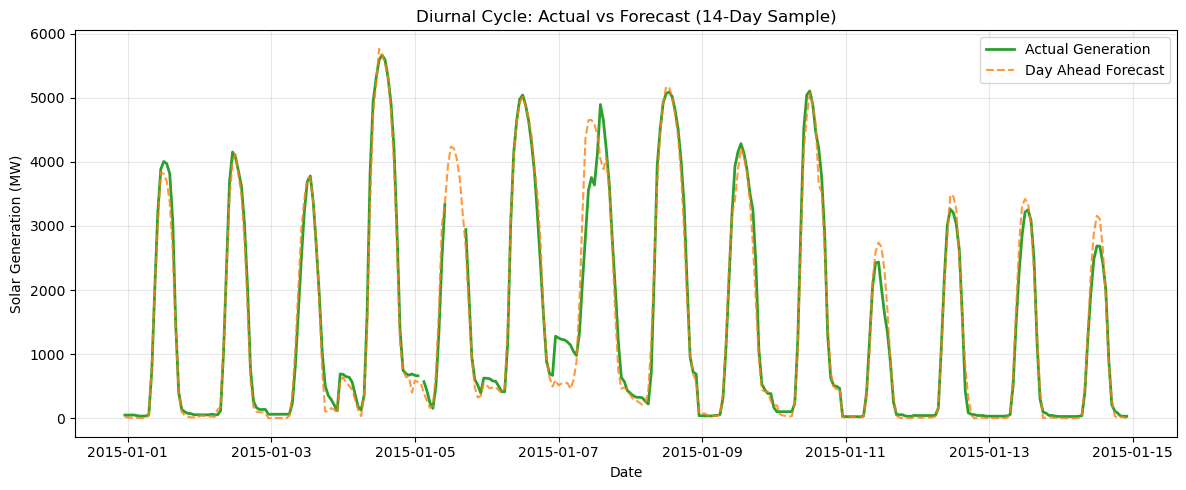

In [22]:
final_df['time'] = pd.to_datetime(final_df['time'], utc=True)
final_df.set_index('time', inplace=True)

plt.figure(figsize=(12, 5))
subset = final_df.iloc[:24*14] 
plt.plot(subset.index, subset['generation solar'], label='Actual Generation', color='#2ca02c', linewidth=2)
plt.plot(subset.index, subset['forecast solar day ahead'], label='Day Ahead Forecast', color='#ff7f0e', linestyle='--', alpha=0.8)
plt.title('Diurnal Cycle: Actual vs Forecast (14-Day Sample)')
plt.ylabel('Solar Generation (MW)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

1) It visually tracks actual solar generation against the grid operator's predictions over a 14-day period.
2) It highlights massive, unpredicted intra-day generation crashes (specifically around January 7th) where the forecast completely failed.

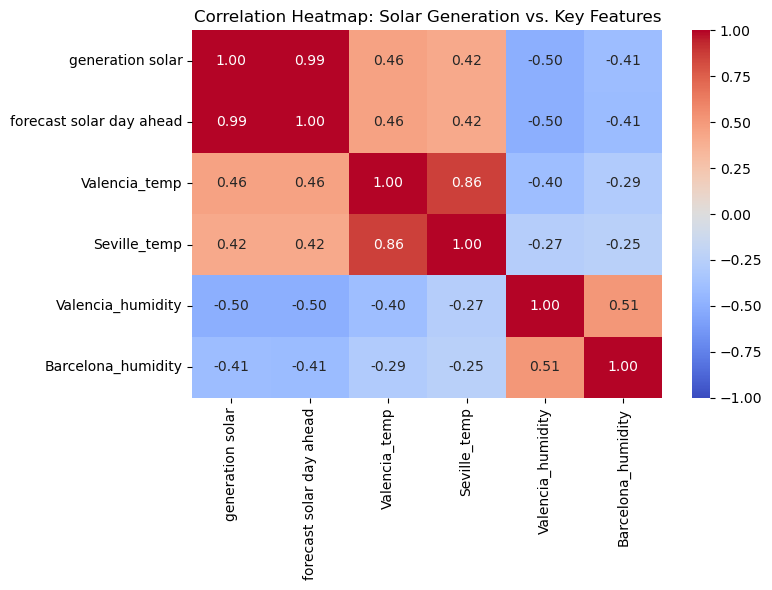

In [23]:
cols_to_plot = ['generation solar', 'forecast solar day ahead', 
                'Valencia_temp', 'Seville_temp', 'Valencia_humidity', 'Barcelona_humidity']

corr_matrix = final_df[cols_to_plot].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Solar Generation vs. Key Features')
plt.tight_layout()
plt.show()

The forecast solar day ahead is nearly perfectly correlated (0.99) with actual generation, confirming it as the primary mathematical anchor for the predictions.

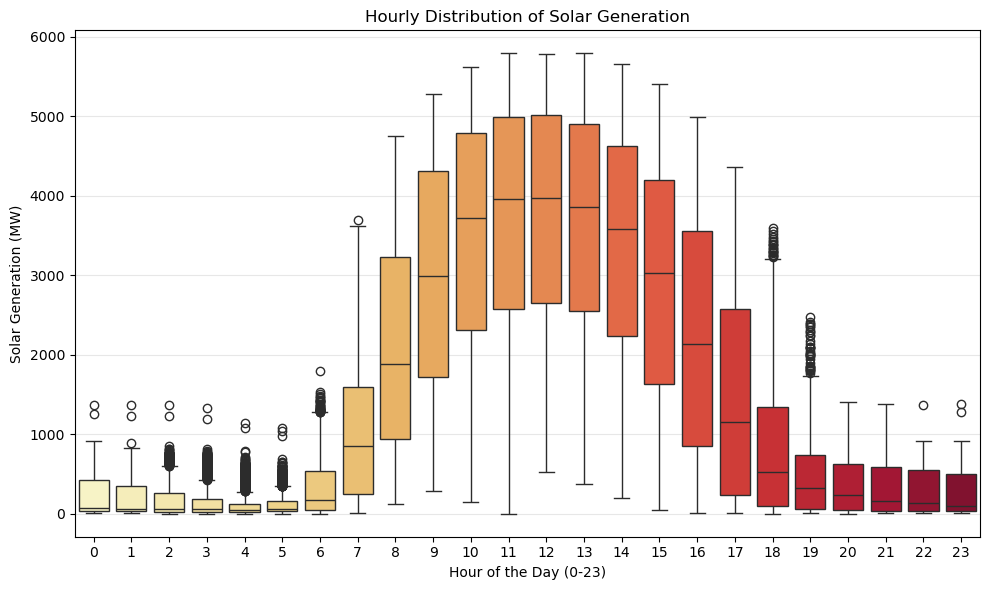

In [24]:
final_df['hour'] = final_df.index.hour

plt.figure(figsize=(10, 6))
sns.boxplot(data=final_df, x='hour', y='generation solar', palette='YlOrRd')
plt.title('Hourly Distribution of Solar Generation')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Solar Generation (MW)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

final_df.drop('hour', axis=1, inplace=True)

Most energy is produced during Hour 8 to Hour 17 (9 hours)

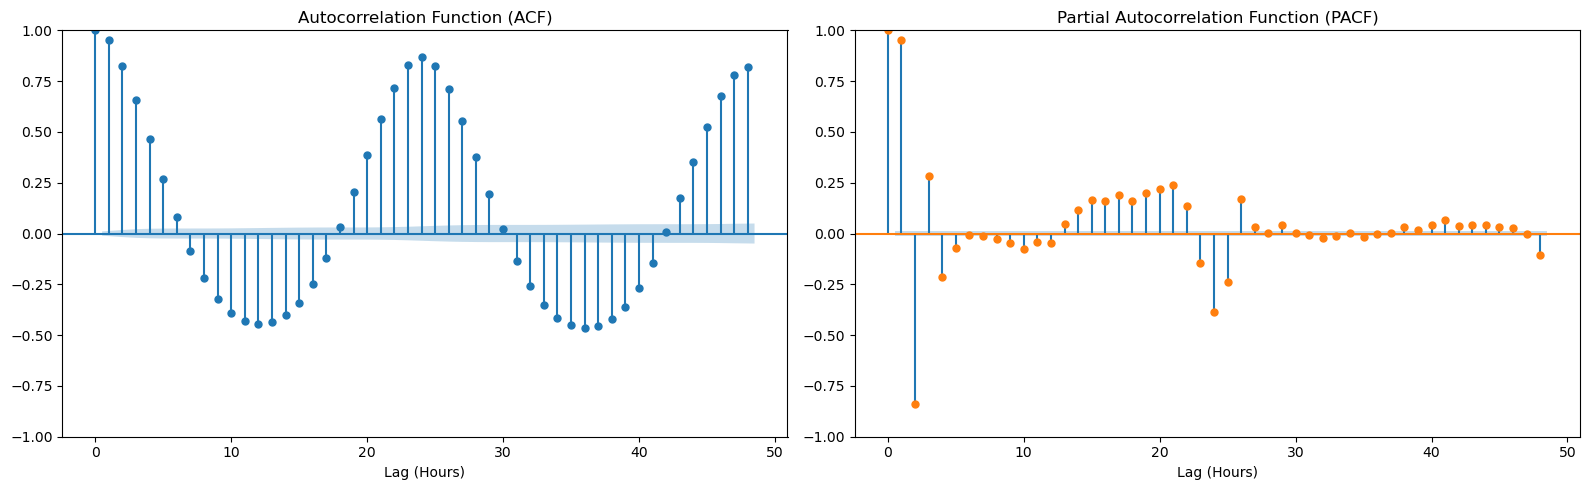

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(final_df['generation solar'].dropna(), lags=48, ax=axes[0], color='#1f77b4')
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].set_xlabel('Lag (Hours)')
plot_pacf(final_df['generation solar'].dropna(), lags=48, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].set_xlabel('Lag (Hours)')
plt.tight_layout()
plt.show()

1) This visualization represents Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots for the generation solar variable over a 48-hour period. These graphs statistically measure how strongly current solar energy generation correlates with past hourly generation data.
2) The ACF plot on the left exhibits a continuous sine-wave pattern with major positive peaks at exactly 24 and 48 hours. This mathematically visualizes the repeating daily cycle of the sun.
3) The PACF plot on the right isolates the direct relationship of specific past hours without the trailing momentum of intermediate hours. The massive spikes at Lag 1 and Lag 2 indicate that the generation output from one and two hours prior are dominant predictive signals.

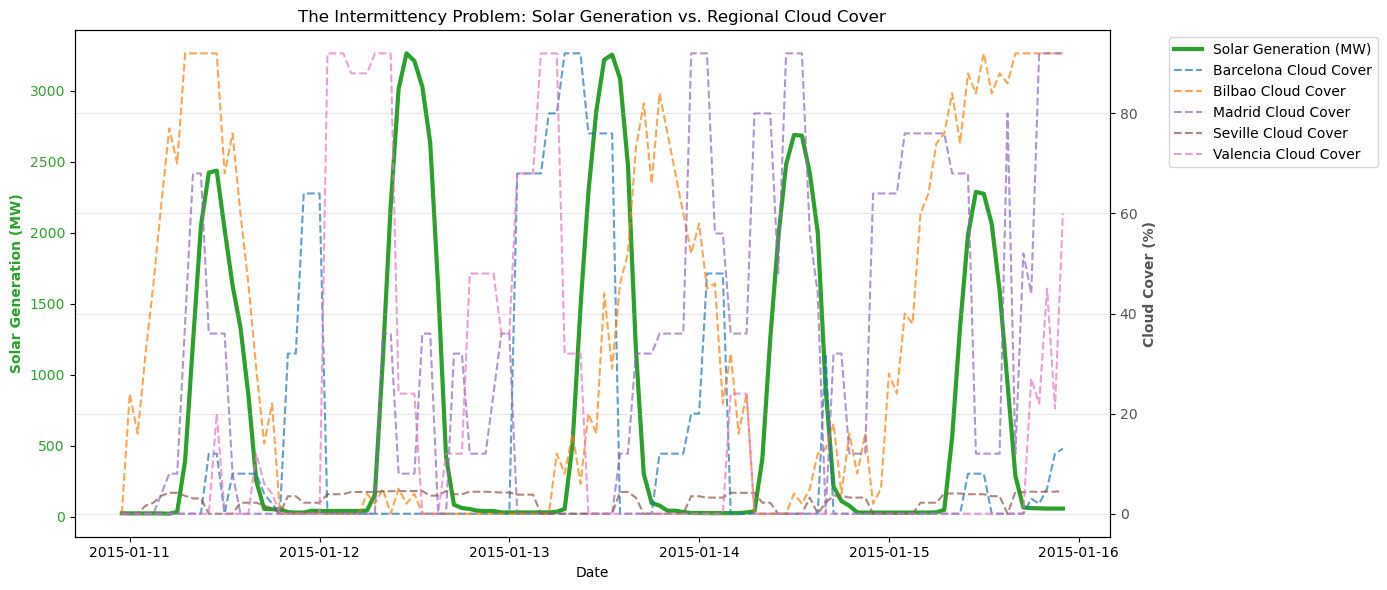

In [26]:
subset = final_df.iloc[24*10:24*15] 

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(subset.index, subset['generation solar'], color='#2ca02c', linewidth=3, label='Solar Generation (MW)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Solar Generation (MW)', color='#2ca02c', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#2ca02c')
ax2 = ax1.twinx()

cities = ['Barcelona', 'Bilbao', 'Madrid', 'Seville', 'Valencia']
colors = ['#1f77b4', '#ff7f0e', '#9467bd', '#8c564b', '#e377c2'] 

for city, color in zip(cities, colors):
    cloud_col = f'{city}_clouds_all'
    ax2.plot(subset.index, subset[cloud_col], color=color, linestyle='--', alpha=0.7, label=f'{city} Cloud Cover')

ax2.set_ylabel('Cloud Cover (%)', color='#555555', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#555555')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', bbox_to_anchor=(1.05, 1))
plt.title('The Intermittency Problem: Solar Generation vs. Regional Cloud Cover')
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

1) The provided graph, titled "The Intermittency Problem: Solar Generation vs. Regional Cloud Cover," is a dual-axis time-series plot that tracks actual solar energy production against the cloud cover percentages of five cities over a five-day period in January 2015.
2) The jagged, erratic movements of the regional cloud cover lines illustrate exactly why solar generation is difficult to predict with a static baseline. A sudden localized cloud front can rapidly alter the national generation total, visually proving to the judges why your machine learning model must rely on regional weather features to capture these intra-day grid fluctuations.

## Data Encoding

In [27]:
final_df.dropna(inplace=True)

In [28]:
# defining a code to encode all the catwgorical columns in a single go
def encode_categorical_columns(df):
  encoders = {}
    
  # Encode each categorical column
  for col in cat_cols:
    unique_values = df[col].unique()
    mapping = {value: i for i, value in enumerate(unique_values)} 
    encoders[col] = mapping
    df[col] = df[col].map(mapping)

  return df, encoders

In [29]:
encode_categorical_columns(final_df)

(                           generation solar  forecast solar day ahead  \
 time                                                                    
 2014-12-31 23:00:00+00:00              49.0                      17.0   
 2015-01-01 00:00:00+00:00              50.0                      16.0   
 2015-01-01 01:00:00+00:00              50.0                       8.0   
 2015-01-01 02:00:00+00:00              50.0                       2.0   
 2015-01-01 03:00:00+00:00              42.0                       9.0   
 ...                                     ...                       ...   
 2018-12-31 18:00:00+00:00              85.0                      96.0   
 2018-12-31 19:00:00+00:00              33.0                      51.0   
 2018-12-31 20:00:00+00:00              31.0                      36.0   
 2018-12-31 21:00:00+00:00              31.0                      29.0   
 2018-12-31 22:00:00+00:00              31.0                      26.0   
 
                            total lo

'clear': 0,'clouds': 1,'rain': 2,'snow': 3,'drizzle': 4,'thunderstorm': 5,'mist': 6,'fog': 7,'dust': 8

In [30]:
final_df.head()

,generation solar,forecast solar day ahead,total load forecast,total load actual,Barcelona_temp,Bilbao_temp,Madrid_temp,Seville_temp,Valencia_temp,Barcelona_pressure,...,Barcelona_weather_main,Bilbao_weather_main,Madrid_weather_main,Seville_weather_main,Valencia_weather_main,Barcelona_weather_description,Bilbao_weather_description,Madrid_weather_description,Seville_weather_description,Valencia_weather_description
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,49.0,17.0,26118.0,25385.0,281.625,269.657312,267.325,273.375,270.475,2.408550,...,0,0,0,0,0,0,0,0,0,0
2015-01-01 00:00:00+00:00,50.0,16.0,24934.0,24382.0,281.625,269.763500,267.325,273.375,270.475,2.408550,...,0,0,0,0,0,0,0,0,0,0
2015-01-01 01:00:00+00:00,50.0,8.0,23515.0,22734.0,281.286,269.251688,266.186,274.086,269.686,2.611712,...,0,0,0,0,0,0,0,0,0,0
2015-01-01 02:00:00+00:00,50.0,2.0,22642.0,21286.0,281.286,269.203344,266.186,274.086,269.686,2.611712,...,0,0,0,0,0,0,0,0,0,0
2015-01-01 03:00:00+00:00,42.0,9.0,21785.0,20264.0,281.286,269.485500,266.186,274.086,269.686,2.611712,...,0,0,0,0,0,0,0,0,0,0


## Train/Test Split

In [31]:
final_df.columns

Index(['generation solar', 'forecast solar day ahead', 'total load forecast',
       'total load actual', 'Barcelona_temp', 'Bilbao_temp', 'Madrid_temp',
       'Seville_temp', 'Valencia_temp', 'Barcelona_pressure',
       'Bilbao_pressure', 'Madrid_pressure', 'Seville_pressure',
       'Valencia_pressure', 'Barcelona_humidity', 'Bilbao_humidity',
       'Madrid_humidity', 'Seville_humidity', 'Valencia_humidity',
       'Barcelona_wind_speed', 'Bilbao_wind_speed', 'Madrid_wind_speed',
       'Seville_wind_speed', 'Valencia_wind_speed', 'Barcelona_wind_deg',
       'Bilbao_wind_deg', 'Madrid_wind_deg', 'Seville_wind_deg',
       'Valencia_wind_deg', 'Barcelona_rain_1h', 'Bilbao_rain_1h',
       'Madrid_rain_1h', 'Seville_rain_1h', 'Valencia_rain_1h',
       'Barcelona_rain_3h', 'Bilbao_rain_3h', 'Madrid_rain_3h',
       'Seville_rain_3h', 'Valencia_rain_3h', 'Barcelona_snow_3h',
       'Bilbao_snow_3h', 'Madrid_snow_3h', 'Seville_snow_3h',
       'Valencia_snow_3h', 'Barcelona_clouds_al

In [32]:
y = final_df['generation solar']
x = final_df.drop(columns='generation solar')

In [33]:
y

time
2014-12-31 23:00:00+00:00    49.0
2015-01-01 00:00:00+00:00    50.0
2015-01-01 01:00:00+00:00    50.0
2015-01-01 02:00:00+00:00    50.0
2015-01-01 03:00:00+00:00    42.0
                             ... 
2018-12-31 18:00:00+00:00    85.0
2018-12-31 19:00:00+00:00    33.0
2018-12-31 20:00:00+00:00    31.0
2018-12-31 21:00:00+00:00    31.0
2018-12-31 22:00:00+00:00    31.0
Name: generation solar, Length: 35023, dtype: float64

In [34]:
x

,forecast solar day ahead,total load forecast,total load actual,Barcelona_temp,Bilbao_temp,Madrid_temp,Seville_temp,Valencia_temp,Barcelona_pressure,Bilbao_pressure,...,Barcelona_weather_main,Bilbao_weather_main,Madrid_weather_main,Seville_weather_main,Valencia_weather_main,Barcelona_weather_description,Bilbao_weather_description,Madrid_weather_description,Seville_weather_description,Valencia_weather_description
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,17.0,26118.0,25385.0,281.625,269.657312,267.325,273.375,270.475,2.408550,1036,...,0,0,0,0,0,0,0,0,0,0
2015-01-01 00:00:00+00:00,16.0,24934.0,24382.0,281.625,269.763500,267.325,273.375,270.475,2.408550,1035,...,0,0,0,0,0,0,0,0,0,0
2015-01-01 01:00:00+00:00,8.0,23515.0,22734.0,281.286,269.251688,266.186,274.086,269.686,2.611712,1036,...,0,0,0,0,0,0,0,0,0,0
2015-01-01 02:00:00+00:00,2.0,22642.0,21286.0,281.286,269.203344,266.186,274.086,269.686,2.611712,1035,...,0,0,0,0,0,0,0,0,0,0
2015-01-01 03:00:00+00:00,9.0,21785.0,20264.0,281.286,269.485500,266.186,274.086,269.686,2.611712,1035,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-31 18:00:00+00:00,96.0,30619.0,30653.0,284.130,281.260000,283.560,287.760,285.640,1.334066,1033,...,0,0,0,0,0,0,0,0,0,0
2018-12-31 19:00:00+00:00,51.0,29932.0,29735.0,282.640,279.810000,280.120,285.760,283.140,1.334066,1034,...,0,0,0,0,0,0,0,0,0,0
2018-12-31 20:00:00+00:00,36.0,27903.0,28071.0,282.140,277.150000,278.150,285.150,281.660,1.446104,1034,...,0,0,0,0,0,0,0,0,0,0


In [35]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.15)

In [36]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(29769, 58)
(5254, 58)
(29769,)
(5254,)


## Model Fitting

In [37]:
lr_model = LinearRegression()

lr_model.fit(x_train, y_train)
y_train_pred = lr_model.predict(x_train)
y_test_pred = lr_model.predict(x_test)

print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_test_pred))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Train R²: 0.9873873859644695
Test R²: 0.9864382295733888
Test MAE: 125.33357903105919
Test MSE: 38245.598893285125


In [38]:
print(final_df.corr(numeric_only=True)[y_train.name].sort_values(ascending=False))

generation solar                 1.000000
forecast solar day ahead         0.993360
Valencia_temp                    0.457061
Seville_temp                     0.416221
Bilbao_temp                      0.399295
total load forecast              0.399277
total load actual                0.396189
Barcelona_temp                   0.386852
Madrid_temp                      0.368648
Barcelona_wind_speed             0.205008
Bilbao_wind_speed                0.185137
Valencia_wind_speed              0.179225
Seville_wind_speed               0.095095
Bilbao_wind_deg                  0.085494
Madrid_wind_speed                0.072235
Valencia_weather_main            0.031825
Valencia_snow_3h                 0.024912
Bilbao_rain_3h                   0.024139
Bilbao_pressure                  0.024094
Madrid_pressure                  0.015408
Madrid_snow_3h                   0.011475
Barcelona_rain_3h                0.009941
Bilbao_snow_3h                   0.004928
Barcelona_weather_main          -0

In [39]:
X = final_df.drop('generation solar', axis=1)
y = final_df['generation solar']

#splitting data into train, validation and test.
train_idx = int(len(final_df) * 0.80)
val_idx = int(len(final_df) * 0.90)

X_train, y_train = X.iloc[:train_idx], y.iloc[:train_idx]
X_val, y_val = X.iloc[train_idx:val_idx], y.iloc[train_idx:val_idx]
X_test, y_test = X.iloc[val_idx:], y.iloc[val_idx:]

In [40]:
# dropping columns that are not useful in model building
cols_to_drop = ['Barcelona_snow_3h', 'Seville_snow_3h']
noise_cols = [
    'Valencia_snow_3h', 'Bilbao_rain_3h', 'Bilbao_pressure', 'Madrid_pressure',
    'Madrid_snow_3h', 'Barcelona_rain_3h', 'Bilbao_snow_3h', 'Valencia_pressure', 
    'Valencia_rain_3h', 'Valencia_clouds_all', 'Barcelona_pressure', 'Bilbao_clouds_all', 
    'Seville_wind_deg', 'Madrid_rain_3h', 'Seville_rain_3h', 'Seville_pressure'
]

X_train = X_train.drop(columns=cols_to_drop + noise_cols, errors='ignore')
X_val = X_val.drop(columns=cols_to_drop + noise_cols, errors='ignore')
X_test = X_test.drop(columns=cols_to_drop + noise_cols, errors='ignore')

# 6. Verify success
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (28018, 40)
X_val shape:   (3502, 40)
X_test shape:  (3503, 40)


In [55]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50, 
    random_state=42
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100)

train_preds = xgb_model.predict(X_train)
val_preds = xgb_model.predict(X_val)
train_r2 = r2_score(y_train, train_preds)
val_r2 = r2_score(y_val, val_preds)
train_mae = mean_absolute_error(y_train, train_preds)
val_mae = mean_absolute_error(y_val, val_preds)

print("\n--- Model Performance ---")
print(f"Training R²:   {train_r2:.4f}  |  Training MAE:   {train_mae:.2f} MW")
print(f"Validation R²: {val_r2:.4f}  |  Validation MAE: {val_mae:.2f} MW")

[0]	validation_0-rmse:1640.16745	validation_1-rmse:1751.49444
[100]	validation_0-rmse:165.87072	validation_1-rmse:260.28752
[200]	validation_0-rmse:143.88683	validation_1-rmse:251.54803
[300]	validation_0-rmse:132.88134	validation_1-rmse:250.81005
[371]	validation_0-rmse:126.15872	validation_1-rmse:250.62036

--- Model Performance ---
Training R²:   0.9939  |  Training MAE:   85.69 MW
Validation R²: 0.9801  |  Validation MAE: 168.80 MW


In [42]:
# dropping 'forecast solar day ahead' due to very high correlation
cols_to_drop_now = ['forecast solar day ahead']

X_train_no_fcst = X_train.drop(columns=cols_to_drop_now, errors='ignore')
X_val_no_fcst = X_val.drop(columns=cols_to_drop_now, errors='ignore')
X_test_no_fcst = X_test.drop(columns=cols_to_drop_now, errors='ignore')

In [43]:
xgb_model_strict = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50, 
    random_state=42
)
xgb_model_strict.fit(
    X_train_no_fcst, y_train,
    eval_set=[(X_train_no_fcst, y_train), (X_val_no_fcst, y_val)],
    verbose=100)

train_preds_strict = xgb_model_strict.predict(X_train_no_fcst)
val_preds_strict = xgb_model_strict.predict(X_val_no_fcst)
train_r2_strict = r2_score(y_train, train_preds_strict)
val_r2_strict = r2_score(y_val, val_preds_strict)
train_mae_strict = mean_absolute_error(y_train, train_preds_strict)
val_mae_strict = mean_absolute_error(y_val, val_preds_strict)

print("\n--- Model Performance (WITHOUT Day-Ahead Forecast) ---")
print(f"Training R²:   {train_r2_strict:.4f}  |  Training MAE:   {train_mae_strict:.2f} MW")
print(f"Validation R²: {val_r2_strict:.4f}  |  Validation MAE: {val_mae_strict:.2f} MW")

[0]	validation_0-rmse:1640.42800	validation_1-rmse:1752.84766
[100]	validation_0-rmse:953.79992	validation_1-rmse:1193.37961
[200]	validation_0-rmse:854.96961	validation_1-rmse:1174.19764
[300]	validation_0-rmse:783.69150	validation_1-rmse:1167.71398
[400]	validation_0-rmse:726.67348	validation_1-rmse:1165.15319
[500]	validation_0-rmse:674.59716	validation_1-rmse:1160.90464
[593]	validation_0-rmse:632.78916	validation_1-rmse:1161.01902

--- Model Performance (WITHOUT Day-Ahead Forecast) ---
Training R²:   0.8477  |  Training MAE:   465.59 MW
Validation R²: 0.5743  |  Validation MAE: 839.48 MW


In [44]:
xgb_model_robust = xgb.XGBRegressor(
    n_estimators=1000,         
    learning_rate=0.05,          
    max_depth=4,                 
    subsample=0.8,               
    colsample_bytree=0.8,        
    early_stopping_rounds=50,   
    random_state=42
)

xgb_model_robust.fit(
    X_train_no_fcst, y_train,
    eval_set=[(X_train_no_fcst, y_train), (X_val_no_fcst, y_val)],
    verbose=100 
)

train_preds = xgb_model_robust.predict(X_train_no_fcst)
val_preds = xgb_model_robust.predict(X_val_no_fcst)

train_r2 = r2_score(y_train, train_preds)
val_r2 = r2_score(y_val, val_preds)

print("\n--- Model Finetuning ---")
print(f"Training R²:   {train_r2:.4f}")
print(f"Validation R²: {val_r2:.4f}")

[0]	validation_0-rmse:1645.41043	validation_1-rmse:1757.15128
[100]	validation_0-rmse:1096.55640	validation_1-rmse:1227.23229
[200]	validation_0-rmse:1035.80620	validation_1-rmse:1206.77451
[300]	validation_0-rmse:995.19894	validation_1-rmse:1196.49231
[400]	validation_0-rmse:964.03302	validation_1-rmse:1188.53657
[500]	validation_0-rmse:934.98178	validation_1-rmse:1181.48418
[600]	validation_0-rmse:910.76882	validation_1-rmse:1179.66435
[680]	validation_0-rmse:893.37063	validation_1-rmse:1178.80939

--- Model Finetuning ---
Training R²:   0.7102
Validation R²: 0.5616


In [56]:
xgb_model_optimized = xgb.XGBRegressor(
    n_estimators=1500,           
    learning_rate=0.03,          
    max_depth=8,               
    subsample=0.85,              
    colsample_bytree=0.85,       
    early_stopping_rounds=100,   
    random_state=42
)
xgb_model_optimized.fit(
    X_train_no_fcst, y_train,
    eval_set=[(X_train_no_fcst, y_train), (X_val_no_fcst, y_val)],
    verbose=100
)

val_preds_opt = xgb_model_optimized.predict(X_val_no_fcst)
new_val_r2 = r2_score(y_val, val_preds_opt)

print("\n--- Model Fine Tuning ---")
print(f"Training R²:   {train_r2:.4f}")
print(f"Validation R²: {val_r2:.4f}")

[0]	validation_0-rmse:1652.52951	validation_1-rmse:1767.78535
[100]	validation_0-rmse:838.84276	validation_1-rmse:1185.64259
[200]	validation_0-rmse:700.74622	validation_1-rmse:1171.53814
[300]	validation_0-rmse:625.94098	validation_1-rmse:1166.12608
[400]	validation_0-rmse:558.66471	validation_1-rmse:1164.98062
[500]	validation_0-rmse:501.83710	validation_1-rmse:1162.65516
[600]	validation_0-rmse:455.54355	validation_1-rmse:1161.71517
[700]	validation_0-rmse:414.17444	validation_1-rmse:1161.49817
[800]	validation_0-rmse:375.21173	validation_1-rmse:1161.33154
[900]	validation_0-rmse:338.87489	validation_1-rmse:1160.09633
[1000]	validation_0-rmse:307.44461	validation_1-rmse:1159.21246
[1100]	validation_0-rmse:280.10115	validation_1-rmse:1158.73715
[1181]	validation_0-rmse:260.74952	validation_1-rmse:1159.29364

--- Model Fine Tuning ---
Training R²:   0.9939
Validation R²: 0.9801


In [46]:
rf_model_no_fcst = RandomForestRegressor(
    n_estimators=200,      
    max_depth=10,          
    min_samples_split=5,   
    n_jobs=-1,             
    random_state=42
)
rf_model_no_fcst.fit(X_train_no_fcst, y_train)
train_preds_rf = rf_model_no_fcst.predict(X_train_no_fcst)
val_preds_rf = rf_model_no_fcst.predict(X_val_no_fcst)

train_r2_rf = r2_score(y_train, train_preds_rf)
val_r2_rf = r2_score(y_val, val_preds_rf)
train_mae_rf = mean_absolute_error(y_train, train_preds_rf)
val_mae_rf = mean_absolute_error(y_val, val_preds_rf)

print("\n--- Random Forest Performance (WITHOUT Day-Ahead Forecast) ---")
print(f"Training R²:   {train_r2_rf:.4f}  |  Training MAE:   {train_mae_rf:.2f} MW")
print(f"Validation R²: {val_r2_rf:.4f}  |  Validation MAE: {val_mae_rf:.2f} MW")


--- Random Forest Performance (WITHOUT Day-Ahead Forecast) ---
Training R²:   0.7369  |  Training MAE:   635.47 MW
Validation R²: 0.5270  |  Validation MAE: 905.81 MW


In [47]:
xgb_model_regularized = xgb.XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=9,               
    min_child_weight=3,       
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,            
    reg_lambda=1.0,             
    early_stopping_rounds=50,    
    random_state=42
)

xgb_model_strict.fit(
    X_train_no_fcst, y_train,
    eval_set=[(X_train_no_fcst, y_train), (X_val_no_fcst, y_val)],
    verbose=100
)

train_preds_strict = xgb_model_strict.predict(X_train_no_fcst)
val_preds_strict = xgb_model_strict.predict(X_val_no_fcst)

train_r2_strict = r2_score(y_train, train_preds_strict)
val_r2_strict = r2_score(y_val, val_preds_strict)
train_mae_strict = mean_absolute_error(y_train, train_preds_strict)
val_mae_strict = mean_absolute_error(y_val, val_preds_strict)

print("\n--- Model Performance After Fine Tuning (Final Model) ---")
print(f"Training R²:   {train_r2_strict:.4f}  |  Training MAE:   {train_mae_strict:.2f} MW")
print(f"Validation R²: {val_r2_strict:.4f}  |  Validation MAE: {val_mae_strict:.2f} MW")

[0]	validation_0-rmse:1640.42800	validation_1-rmse:1752.84766
[100]	validation_0-rmse:953.79992	validation_1-rmse:1193.37961
[200]	validation_0-rmse:854.96961	validation_1-rmse:1174.19764
[300]	validation_0-rmse:783.69150	validation_1-rmse:1167.71398
[400]	validation_0-rmse:726.67348	validation_1-rmse:1165.15319
[500]	validation_0-rmse:674.59716	validation_1-rmse:1160.90464
[593]	validation_0-rmse:632.78916	validation_1-rmse:1161.01902

--- Model Performance After Fine Tuning (Final Model) ---
Training R²:   0.8477  |  Training MAE:   465.59 MW
Validation R²: 0.5743  |  Validation MAE: 839.48 MW
